In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\BCI_classifier


In [14]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns

In [19]:
metrics = ['accuracy', 'balanced accuracy', 'roc-auc', 'f1', 'recall',
       'precision', 'TPR', 'TNR', 'FPR', 'FNR', 'TP', 'TN', 'FP', 'FN',
       'brier score', 'log loss']

In [10]:
filename = r"..\results\pr_Agency_EBCI\test\04_03 Artem\cv_scores\04_calib.xlsx"
df = pd.read_excel(filename)
pipes = df.pipeline.unique()
pipes

<StringArray>
['csp_before_split', 'split_before_csp']
Length: 2, dtype: str

In [28]:
df_fair = df.loc[df.pipeline == "split_before_csp"]
df_simple = df.loc[df.pipeline == "csp_before_split"]

In [35]:
band = "[8, 12]"
def avg_df(df, band):
    return df.loc[df.band == band][metrics].mean()
metric = ['brier score', 'log loss']
avg_df(df_simple, band)[metric], avg_df(df_fair, band)[metric] 

(brier score    0.065513
 log loss       0.298360
 dtype: float64,
 brier score    0.165282
 log loss       0.776400
 dtype: float64)

<Axes: >

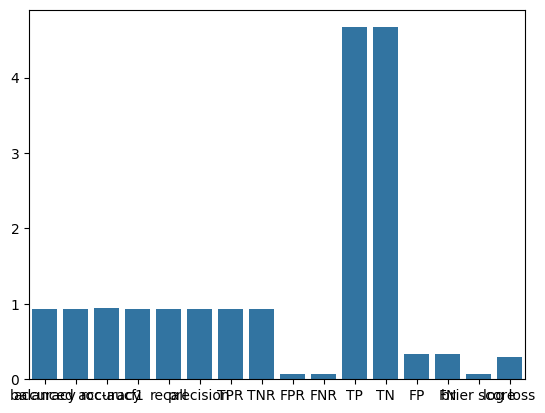

In [33]:
sns.barplot(avg_df(df_simple, band))